<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/environment/U_net_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Create a an start pix
def create_star(size=124, num_stars=5, target_snr=20):
  # 1. Create grid (image)
  image = np.zeros((size, size))

  x = np.arange(size)
  y = np.arange(size)
  X, Y = np.meshgrid(x, y)

  # add multiple stars
  for _ in range(num_stars):
    # 2. Parameters
    # A0 = np.random.randint(100, 500)       # total intensity (flux)
    FWHM = np.random.randint(4, 32)
    sigma = FWHM / 2.355 # spread (size of star)
    A0 = np.random.randint(4, 32) * 2 * np.pi * (sigma**2)


    x0 = np.random.randint(0, size)        # center x (x')
    y0 = np.random.randint(0, size)        # center y (y')

    # 3. Gaussian star formula
    star = (A0 / (2 * np.pi * sigma**2)) * np.exp(
        -((X - x0)**2 + (Y - y0)**2) / (2 * sigma**2)
    )
    image += star

    #  Add white Gaussian noise
    noise = np.random.normal(0, 1, image.shape)
    noisy_image = image + noise
  return image , noisy_image


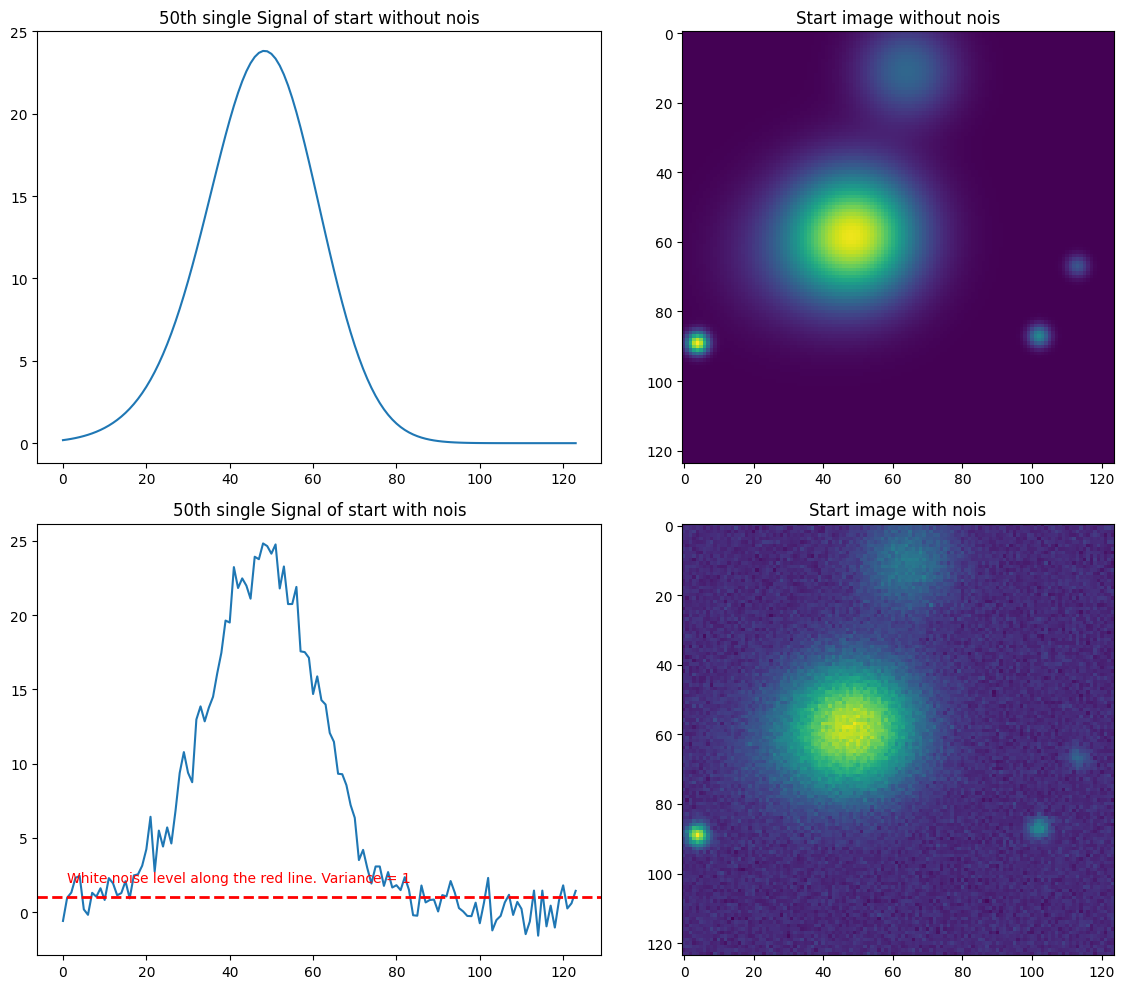

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
num_stars = np.random.randint(2, 10)
signal_num = 50
star, noisy_star = create_star(num_stars=num_stars)
ax[0, 0].plot(star[signal_num, :])
ax[0, 0].set_title(f"{signal_num}th single Signal of start without nois")
ax[1, 0].plot(noisy_star[signal_num, :])
ax[1, 0].set_title(f"{signal_num}th single Signal of start with nois")
ax[1, 0].axhline(y=1, color='red', linestyle='--', linewidth=2)
ax[1, 0].text(1, 2, 'White noise level along the red line. Variance = 1', color='red')


ax[0, 1].imshow(star)
ax[0, 1].set_title(f"Start image without nois")
ax[1, 1].imshow(noisy_star)
ax[1, 1].set_title(f"Start image with nois")

plt.tight_layout()
plt.show()

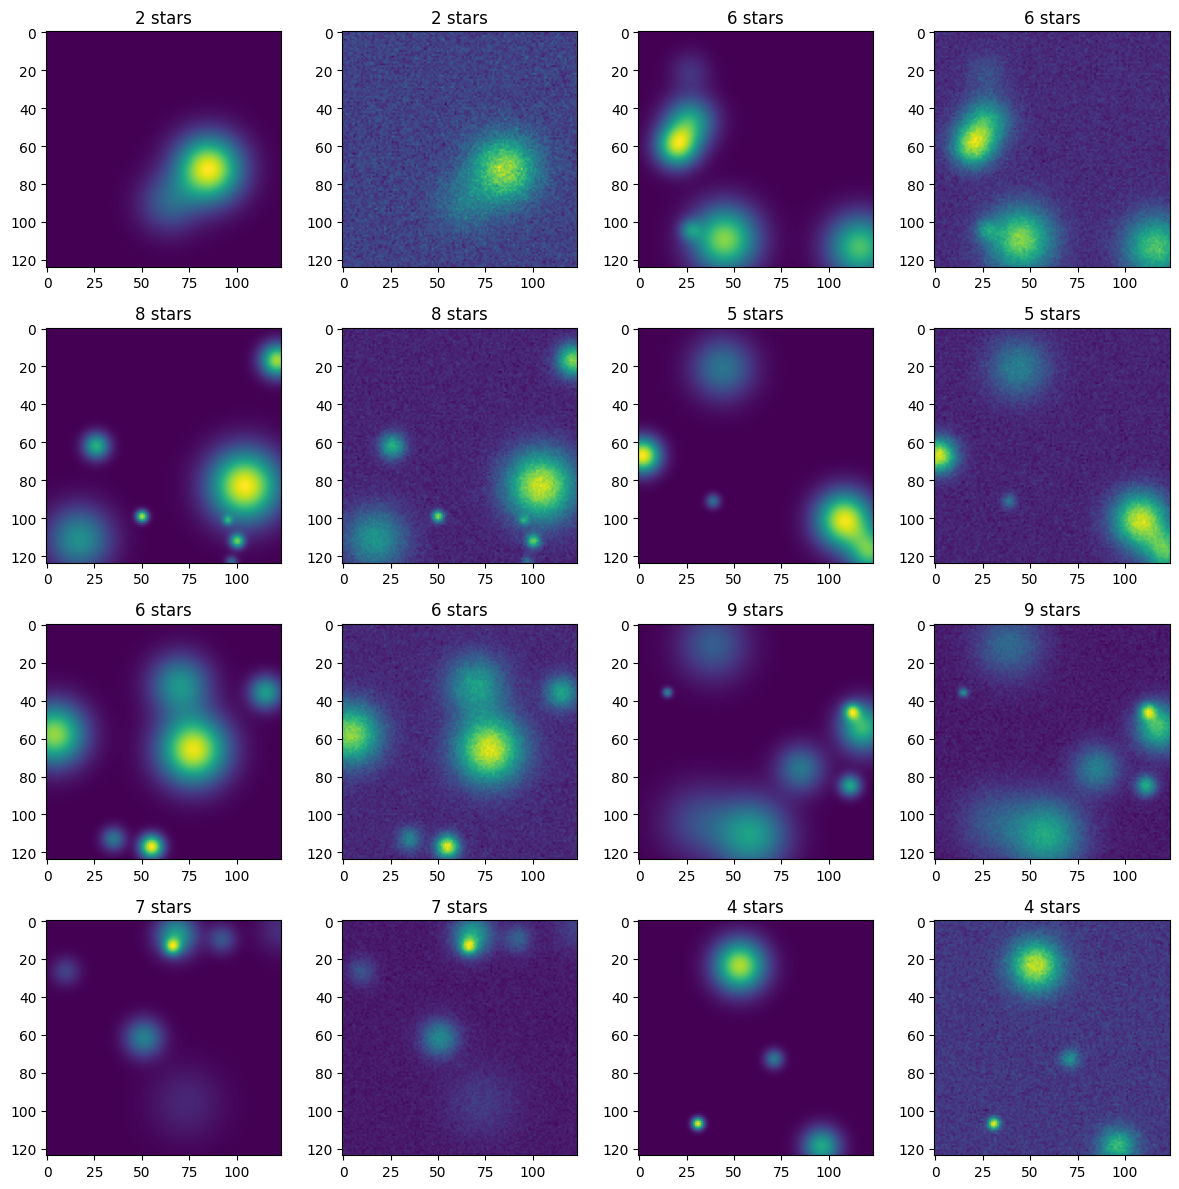

In [ ]:
# plot some starts with nois
plt.figure(figsize=(12, 12))
for i in range(8):
  num_stars = np.random.randint(2, 10)
  star, noisy_star = create_star(num_stars=num_stars)
  plt.subplot(4, 4, 2*i+1)
  plt.title(f"{num_stars} stars")
  plt.imshow(star)

  plt.subplot(4, 4, 2*i+2)
  plt.title(f"{num_stars} stars")
  plt.imshow(noisy_star)
plt.tight_layout()
plt.show()

In [ ]:
training_data =[]
training_data_noisy =[]
for _ in range(100):
  num_stars = np.random.randint(2, 10)
  star, noisy_star = create_star(num_stars=num_stars)
  training_data.append(star)
  training_data_noisy.append(noisy_star)
training_data = np.array(training_data)
training_data_noisy = np.array(training_data_noisy)

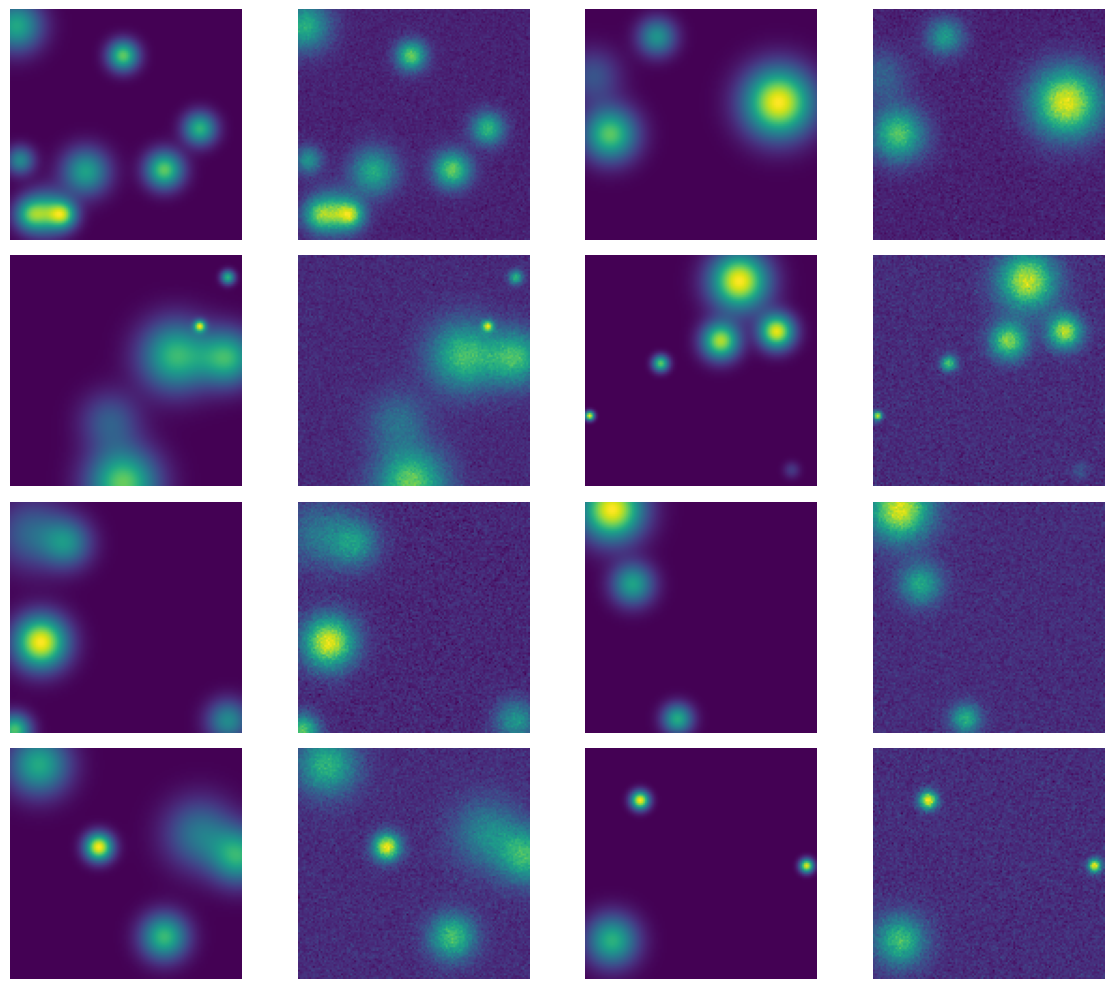

In [ ]:
# plot some random images
plt.figure(figsize=(12, 10))
random_idx = np.random.randint(0, len(training_data), size=8)
for i, (star, noisy_star) in enumerate(zip(training_data[random_idx], training_data_noisy[random_idx])):
  plt.subplot(4, 4, 2*i+1)
  plt.imshow(star)
  plt.axis(False)

  plt.subplot(4, 4, 2*i+2)
  plt.imshow(noisy_star)
  plt.axis(False)
plt.tight_layout()